In [61]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import random_split
from datetime import datetime
import numpy as np
from torch.utils.data import Dataset
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image


# Getting the same results with train and train_manual_update
- Write torch.manual_seed(42) at the beginning of your notebook.
- Write torch.set_default_dtype(torch.double) at the beginning of your notebook to alleviate precision errors

In [62]:
torch.manual_seed(42)
torch.set_default_dtype(torch.double)

# Tasks
Load, analyse and preprocess the CIFAR-10 dataset. Split it into 3
datasets: training, validation and test. Take a subset of these datasets
by keeping only 2 labels: cat and car

In [ ]:
def show_img(img, label) -> None:
    img = img.squeeze().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

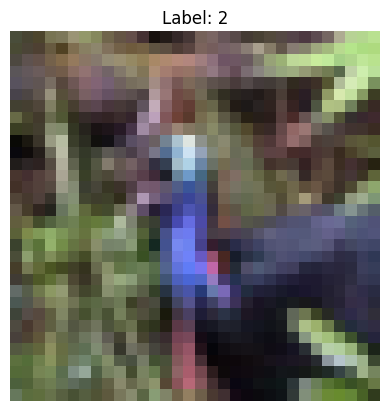

In [ ]:
class CIFAR2(Dataset):
    def __init__(self, data_path: Path):
        self.data_path = data_path
        self.data, self.targets = self.__loaddata__()
        self.transform = transforms.ToTensor()

    def __loaddata__(self):
        data = datasets.CIFAR10(
            root=str(self.data_path),
            transform=None,
            download=True
        )
        targets = np.array(data.targets)
        indices = (targets == 0) | (targets == 2) # plane, bird
        return data.data[indices], targets[indices]

    def __getitem__(self, idx) -> tuple[torch.Tensor, int]:
        img, target = self.data[idx], self.targets[idx]        
        return self.transform(Image.fromarray(img)), target

    def __len__(self):
        return len(self.data)

cifar = CIFAR2("data/")
img, label = cifar[3]
show_img(img, label)

In [ ]:
def load_cifar(train_val_split=0.9, data_path='data/', preprocessor=None):
    cifar2 = CIFAR2(Path(data_path))

    train_size = int(len(cifar2) * train_val_split)
    val_test_size = len(cifar2) - train_size

    cifar_generator = torch.Generator().manual_seed(42)
    train, val_test = random_split(cifar2, lengths=[train_size, val_test_size], generator=cifar_generator)
    
    test_val_split = 0.5 # 0.05, 0.05
    val_size = int(len(val_test) * test_val_split)
    test_size = len(val_test) - val_size
    
    val, test = random_split(val_test, lengths=[val_size, test_size], generator=cifar_generator)

    # use resampler

    # use dataloader
    transform=transforms.ToTensor(),

    
    return train, val, test

def compute_accuracy(model, loader):
 data = load_cifar()
#  train
 #TODO
 return 

Write a MyMLP class that implements a MLP in PyTorch (so only fully
connected layers) such that:
    
    - The input dimension is 768(= 16 ∗ 16 ∗ 3) and the output dimension is 2 (for the 2 classes).
    - The hidden layers have respectively 128 and 32 hidden units.
    - All activation functions are ReLU. The last layer has no activation function since the cross-entropy loss already includes a softmax activation
function.

In [ ]:
class MyNet(nn.Module):
    #TODO

SyntaxError: incomplete input (2919787615.py, line 2)

Write a train(n_epochs, optimizer, model, loss_fn, train_loader) function that trains model for n_epochs epochs given an optimizer optimizer, a loss function loss_fn and a dataloader train_loader.

In [ ]:
def train(n_epochs, optimizer, model, loss_fn, train_loader):
 #TODO


Write a similar function train manual_update that has no optimizer parameter, but a learning rate lr parameter instead and that manually updates each trainable parameter of model using equation (2). Do not forget to zero out all gradients after each iteration. 

Train 2 instances of MyMLP, one using train and the other using train_manual_update (use the same parameter values for both models). Compare their respective training losses. To get exactly the same results with both functions, see section 3.3

In [ ]:
def train_manual_update(n_epochs, model, loss_fn, train_loader, lr=1e-2, momentum_coeff=0., weight_decay=0.):
    #TODO